In [ ]:
# Lab 5b
# Fine tuning models

In [2]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as transforms
import torchvision.io as tv_io

import glob
import json
from PIL import Image
import platform

import utils

In [3]:
def get_platform_device():
    '''

    Detects the OS and the best GPU to use on the device

    '''
    
    os_name = platform.system()
    processor = platform.processor()
    

    if torch.cuda.is_available():
        device = torch.device("cuda")
        platform_info = f"Nvidia GPU via CUDA ({os_name})"
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        platform_info = f"Apple Silicon via MPS ({os_name})"
    else:
        device = torch.device("cpu")
        platform_info = f"CPU fallback ({os_name} {processor})"
    
    print(f"Platform detected: {platform_info}")
    return device

device = get_platform_device()
print(f"Using device: {device}")

Platform detected: Apple Silicon via MPS (Darwin)
Using device: mps


In [3]:
from torchvision.models import vgg16
from torchvision.models import VGG16_Weights

# load the VGG16 network *pre-trained* on the ImageNet dataset
weights = VGG16_Weights.DEFAULT
vgg_model = vgg16(weights=weights)

In [4]:
vgg_model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [5]:
vgg_model.requires_grad_(False)
print("VGG16 Frozen")

VGG16 Frozen


In [6]:
N_CLASSES = 1

my_model = nn.Sequential(
    vgg_model,
    nn.Linear(1000, N_CLASSES)
)

my_model.to(device)

Sequential(
  (0): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
      (16): M

In [7]:
for idx, param in enumerate(my_model.parameters()):
    print(idx, param.requires_grad)

0 False
1 False
2 False
3 False
4 False
5 False
6 False
7 False
8 False
9 False
10 False
11 False
12 False
13 False
14 False
15 False
16 False
17 False
18 False
19 False
20 False
21 False
22 False
23 False
24 False
25 False
26 False
27 False
28 False
29 False
30 False
31 False
32 True
33 True


In [8]:
vgg_model.requires_grad_(True)
print("VGG16 Unfrozen")
for idx, param in enumerate(my_model.parameters()):
    print(idx, param.requires_grad)

VGG16 Unfrozen
0 True
1 True
2 True
3 True
4 True
5 True
6 True
7 True
8 True
9 True
10 True
11 True
12 True
13 True
14 True
15 True
16 True
17 True
18 True
19 True
20 True
21 True
22 True
23 True
24 True
25 True
26 True
27 True
28 True
29 True
30 True
31 True
32 True
33 True


In [9]:
vgg_model.requires_grad_(False)
print("VGG16 Frozen")

VGG16 Frozen


In [10]:
loss_function = nn.BCEWithLogitsLoss()
optimizer = Adam(my_model.parameters())
my_model = my_model.to(device)

In [11]:
pre_trans = weights.transforms()

In [12]:
DATA_LABELS = ["bo", "not_bo"] 
    
class MyDataset(Dataset):
    def __init__(self, data_dir):
        self.imgs = []
        self.labels = []
        
        for l_idx, label in enumerate(DATA_LABELS):
            data_paths = glob.glob(data_dir + label + '/*.jpg', recursive=True)
            for path in data_paths:
                img = Image.open(path)
                self.imgs.append(pre_trans(img).to(device))
                self.labels.append(torch.tensor(l_idx).to(device).float())


    def __getitem__(self, idx):
        img = self.imgs[idx]
        label = self.labels[idx]
        return img, label

    def __len__(self):
        return len(self.imgs)

In [13]:
n = 32

train_path = "data/presidential_doggy_door/train/"
train_data = MyDataset(train_path)
train_loader = DataLoader(train_data, batch_size=n, shuffle=True)
train_N = len(train_loader.dataset)

valid_path = "data/presidential_doggy_door/valid/"
valid_data = MyDataset(valid_path)
valid_loader = DataLoader(valid_data, batch_size=n)
valid_N = len(valid_loader.dataset)

In [14]:
IMG_WIDTH, IMG_HEIGHT = (224, 224)

random_trans = transforms.Compose([
    transforms.RandomRotation(25),
    transforms.RandomResizedCrop((IMG_WIDTH, IMG_HEIGHT), scale=(.8, 1), ratio=(1, 1)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=.2, contrast=.2, saturation=.2, hue=.2)
])

In [15]:
def get_batch_accuracy(output, y, N):
    zero_tensor = torch.tensor([0]).to(device)
    pred = torch.gt(output, zero_tensor)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

In [16]:
def train(model, check_grad=False):
    loss = 0
    accuracy = 0

    model.train()
    for x, y in train_loader:
        output = torch.squeeze(model(random_trans(x)))
        optimizer.zero_grad()
        batch_loss = loss_function(output, y)
        batch_loss.backward()
        optimizer.step()

        loss += batch_loss.item()
        accuracy += get_batch_accuracy(output, y, train_N)
    if check_grad:
        print('Last Gradient:')
        for param in model.parameters():
            print(param.grad)
    print('Train - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

In [17]:
def validate(model):
    loss = 0
    accuracy = 0

    model.eval()
    with torch.no_grad():
        for x, y in valid_loader:
            output = torch.squeeze(model(x))

            loss += loss_function(output, y.float()).item()
            accuracy += get_batch_accuracy(output, y, valid_N)
    print('Valid - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

In [18]:
def train_model(epochs: int) -> None:
    for epoch in range(epochs):
        print('Epoch: {}'.format(epoch+1))
        train(my_model, check_grad=False)
        validate(my_model)
    print("Complete")

In [19]:
train_model(10)

Epoch: 1
Train - Loss: 2.0165 Accuracy: 0.8015
Valid - Loss: 1.6609 Accuracy: 0.6000
Epoch: 2
Train - Loss: 2.3929 Accuracy: 0.8473
Valid - Loss: 1.7790 Accuracy: 0.6667
Epoch: 3
Train - Loss: 2.1569 Accuracy: 0.8550
Valid - Loss: 1.5070 Accuracy: 0.6667
Epoch: 4
Train - Loss: 1.8184 Accuracy: 0.8092
Valid - Loss: 1.1908 Accuracy: 0.6667
Epoch: 5
Train - Loss: 1.4341 Accuracy: 0.8550
Valid - Loss: 0.9164 Accuracy: 0.6667
Epoch: 6
Train - Loss: 1.4910 Accuracy: 0.8626
Valid - Loss: 0.6267 Accuracy: 0.7000
Epoch: 7
Train - Loss: 1.2974 Accuracy: 0.8626
Valid - Loss: 0.3674 Accuracy: 0.8000
Epoch: 8
Train - Loss: 1.3737 Accuracy: 0.8626
Valid - Loss: 0.2314 Accuracy: 0.8667
Epoch: 9
Train - Loss: 1.3566 Accuracy: 0.8550
Valid - Loss: 0.1740 Accuracy: 0.9333
Epoch: 10
Train - Loss: 1.1087 Accuracy: 0.8931
Valid - Loss: 0.1318 Accuracy: 0.9667
Complete


In [20]:
vgg_model.requires_grad_(True)
optimizer = Adam(my_model.parameters(), lr=.000001)

In [21]:
train_model(2)

Epoch: 1
Train - Loss: 0.9130 Accuracy: 0.9160
Valid - Loss: 0.1327 Accuracy: 0.9667
Epoch: 2
Train - Loss: 1.3213 Accuracy: 0.8855
Valid - Loss: 0.1324 Accuracy: 0.9667
Complete


In [23]:
from utils import show_image

In [24]:
def make_prediction(file_path):
    show_image(file_path)
    image = Image.open(file_path)
    image = pre_trans(image).to(device)
    image = image.unsqueeze(0)
    output = my_model(image)
    prediction = output.item()
    return prediction

-3.539706230163574

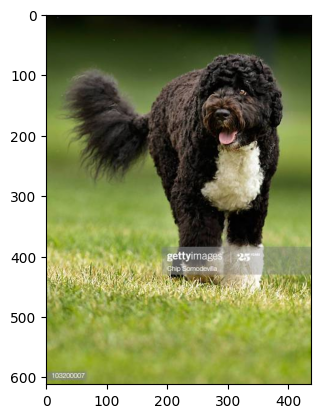

In [26]:
make_prediction('data/presidential_doggy_door/valid/bo/bo_20.jpg')

5.598537921905518

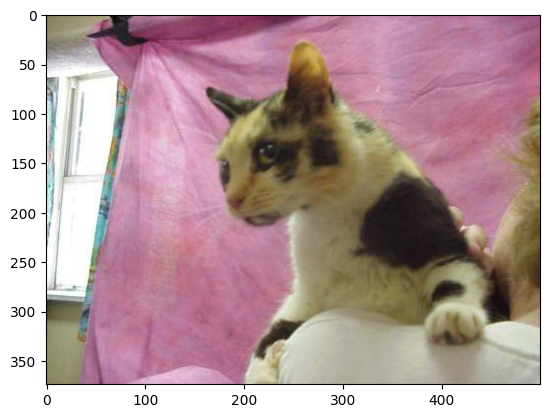

In [29]:
make_prediction('data/presidential_doggy_door/valid/not_bo/121.jpg')

In [30]:
def presidential_doggy_door(image_path: str) -> str:
    pred = make_prediction(image_path)
    return "It's a Bo! Let him in!" if pred < 0 else "That's not Bo! Stay Out!"

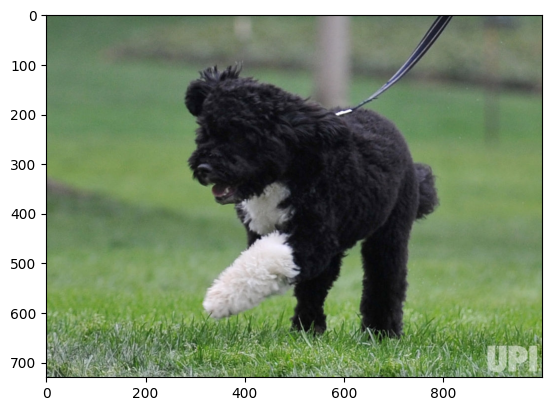

In [34]:
not_bo = presidential_doggy_door('data/presidential_doggy_door/valid/not_bo/131.jpg')
bo = presidential_doggy_door('data/presidential_doggy_door/valid/bo/bo_29.jpg')

In [35]:
print(not_bo)

That's not Bo! Stay Out!


In [36]:
print(bo)

It's a Bo! Let him in!


In [37]:
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}